# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-23 22:21:51.992055: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 22:21:51.993786: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 22:21:52.018735: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 22:21:52.018770: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 22:21:52.018787: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /home/chetanm/tinyml_env_setup_package/UCI HAR Dataset


## 3. Load the Data


In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype=np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:
def build_teacher_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [6]:
teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1898 - val_accuracy: 0.9205
Epoch 2/40
92/92 [==============================] - 1s 9ms/step - loss: 0.1608 - accuracy: 0.9347 - val_loss: 0.1402 - val_accuracy: 0.9395
Epoch 3/40
92/92 [==============================] - 2s 20ms/step - loss: 0.1041 - accuracy: 0.9568 - val_loss: 0.4059 - val_accuracy: 0.8620
Epoch 4/40
92/92 [==============================] - 1s 9ms/step - loss: 0.0926 - accuracy: 0.9638 - val_loss: 0.1777 - val_accuracy: 0.9347
Epoch 5/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0904 - accuracy: 0.9645 - val_loss: 0.1641 - val_accuracy: 0.9286


### Teacher Training Curves


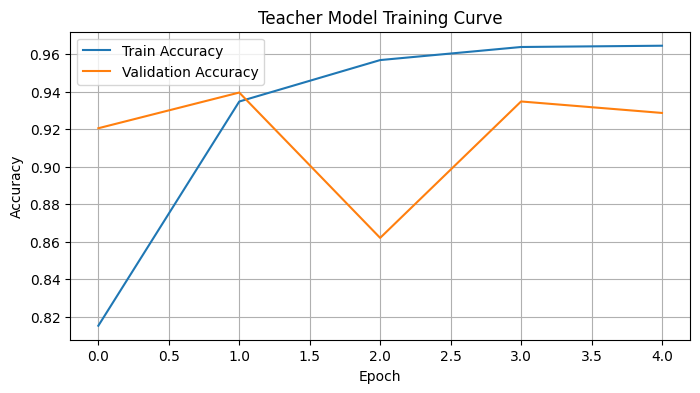

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [8]:
student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.6947 - accuracy: 0.7674 - val_loss: 0.3262 - val_accuracy: 0.8906
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.2689 - accuracy: 0.9078 - val_loss: 0.2485 - val_accuracy: 0.9137
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1705 - accuracy: 0.9441 - val_loss: 0.2348 - val_accuracy: 0.9157
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1358 - accuracy: 0.9534 - val_loss: 0.1561 - val_accuracy: 0.9320
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1074 - accuracy: 0.9621 - val_loss: 0.1495 - val_accuracy: 0.9279
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0854 - accuracy: 0.9725 - val_loss: 0.2112 - val_accuracy: 0.9293
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0778 - accuracy: 0.9747 - val_loss: 0.1267 - val_accuracy: 0.9436
Epoch 8/40
92/92 [==

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


Epoch 1/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0791 - accuracy: 0.9716 - val_loss: 0.1439 - val_accuracy: 0.9402
Epoch 2/20
92/92 [==============================] - 0s 1ms/step - loss: 0.0684 - accuracy: 0.9757 - val_loss: 0.1460 - val_accuracy: 0.9395
Epoch 3/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0543 - accuracy: 0.9821 - val_loss: 0.1687 - val_accuracy: 0.9415
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0567 - accuracy: 0.9793 - val_loss: 0.1437 - val_accuracy: 0.9429
Epoch 5/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0521 - accuracy: 0.9810 - val_loss: 0.1344 - val_accuracy: 0.9443
Epoch 6/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0454 - accuracy: 0.9842 - val_loss: 0.1610 - val_accuracy: 0.9470
Epoch 7/20
92/92 [==============================] - 0s 2ms/step - loss: 0.0642 - accuracy: 0.9762 - val_loss: 0.1637 - val_accuracy: 0.9429
Epoch 8/20
92/92 [==

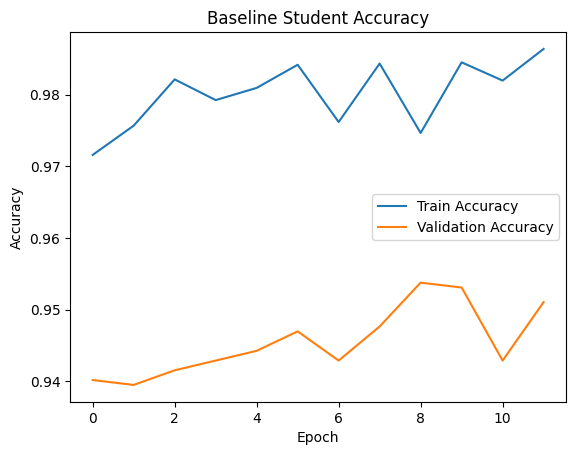

In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


plt.figure()
plt.plot(student_baseline_history.history['accuracy'], label='Train Accuracy')
plt.plot(student_baseline_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Baseline Student Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 9. Evaluate the Baseline Student Model


In [10]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)

            teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature, axis=1)
            student_soft = tf.nn.softmax(student_predictions / self.temperature, axis=1)
            distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft)

            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [11]:
distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 3ms/step - accuracy: 0.7264 - student_loss: 0.7664 - distillation_loss: 0.0020 - val_accuracy: 0.8980 - val_student_loss: 0.1825
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9007 - student_loss: 0.2849 - distillation_loss: 5.7538e-04 - val_accuracy: 0.9157 - val_student_loss: 0.0189
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9254 - student_loss: 0.1921 - distillation_loss: 3.1878e-04 - val_accuracy: 0.9300 - val_student_loss: 0.0095
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9485 - student_loss: 0.1407 - distillation_loss: 1.9630e-04 - val_accuracy: 0.9286 - val_student_loss: 0.0062
Epoch 5/40
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9600 - student_loss: 0.1120 - distillation_loss: 1.6152e-04 - val_accuracy: 0.9286 - val_student_loss: 0.0024
Epoch 6/40
92/92 [==============================] - 1s 7ms/step 

## 11. Train the Distilled Student


In [12]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 3ms/step - accuracy: 0.7155 - student_loss: 0.7477 - distillation_loss: 0.0019 - val_accuracy: 0.8878 - val_student_loss: 0.0936
Epoch 2/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9055 - student_loss: 0.2718 - distillation_loss: 5.2941e-04 - val_accuracy: 0.9218 - val_student_loss: 0.0146
Epoch 3/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9340 - student_loss: 0.1810 - distillation_loss: 2.8910e-04 - val_accuracy: 0.9320 - val_student_loss: 0.0101
Epoch 4/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9532 - student_loss: 0.1342 - distillation_loss: 1.8828e-04 - val_accuracy: 0.9368 - val_student_loss: 0.0060
Epoch 5/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9592 - student_loss: 0.1144 - distillation_loss: 1.6615e-04 - val_accuracy: 0.9341 - val_student_loss: 0.0020
Epoch 6/20
92/92 [==============================] - 1s 5ms/step 

### Distillation Training Curves


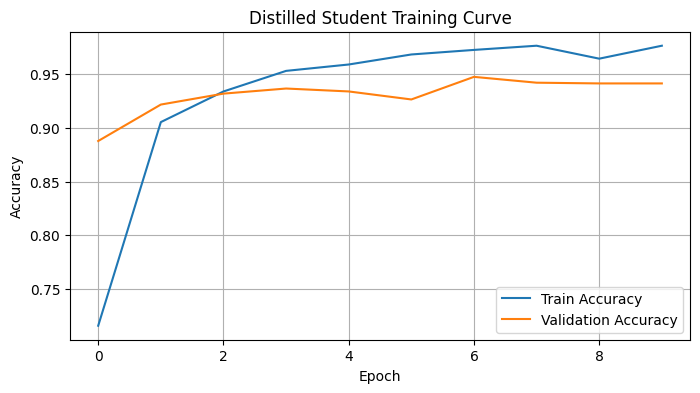

In [13]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9406

                    precision    recall  f1-score   support

           WALKING     0.9620    0.9698    0.9659       496
  WALKING_UPSTAIRS     0.9255    0.9490    0.9371       471
WALKING_DOWNSTAIRS     0.9435    0.9143    0.9287       420
           SITTING     0.9189    0.9002    0.9095       491
          STANDING     0.8964    0.9267    0.9113       532
            LAYING     0.9981    0.9777    0.9878       537

          accuracy                         0.9406      2947
         macro avg     0.9407    0.9396    0.9400      2947
      weighted avg     0.9411    0.9406    0.9407      2947



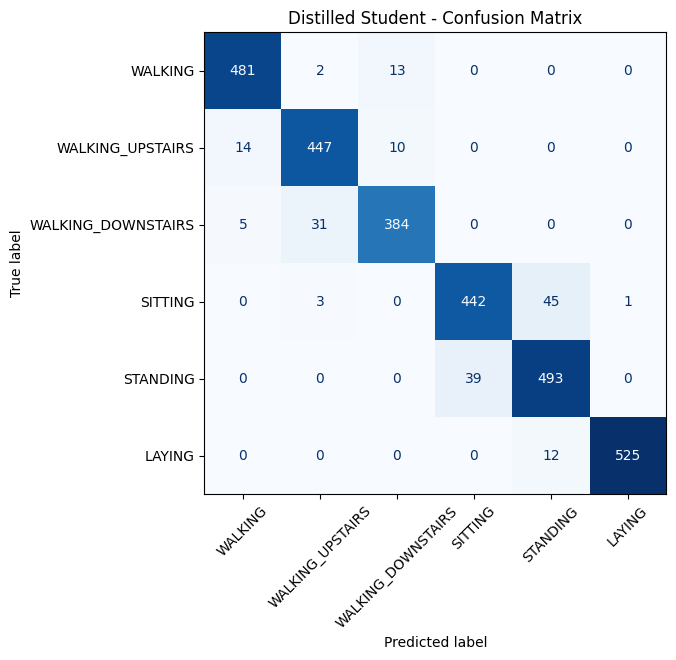

In [14]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [15]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = x / input_scale + input_zero_point
            x = np.clip(np.round(x), -128, 127).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = x / input_scale + input_zero_point
            x = np.clip(np.round(x), 0, 255).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [16]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point)
            x = np.clip(x, -128, 127).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point)
            x = np.clip(x, 0, 255).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(300, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]


## 15. Convert the Distilled Student to TensorFlow Lite


In [17]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)


Epoch 1/10
92/92 [==============================] - 1s 3ms/step - loss: 0.0655 - accuracy: 0.9808 - val_loss: 0.1199 - val_accuracy: 0.9429
Epoch 2/10
92/92 [==============================] - 0s 2ms/step - loss: 0.0718 - accuracy: 0.9806 - val_loss: 0.1327 - val_accuracy: 0.9402
Epoch 3/10
92/92 [==============================] - 0s 2ms/step - loss: 0.0834 - accuracy: 0.9781 - val_loss: 0.1320 - val_accuracy: 0.9436
Epoch 4/10
92/92 [==============================] - 0s 3ms/step - loss: 0.1658 - accuracy: 0.9583 - val_loss: 0.1753 - val_accuracy: 0.9483
Epoch 5/10
92/92 [==============================] - 0s 3ms/step - loss: 0.2251 - accuracy: 0.9561 - val_loss: 0.2144 - val_accuracy: 0.9524
Epoch 6/10
92/92 [==============================] - 0s 2ms/step - loss: 0.3730 - accuracy: 0.8667 - val_loss: 0.2483 - val_accuracy: 0.9388
Epoch 7/10
92/92 [==============================] - 0s 3ms/step - loss: 0.8359 - accuracy: 0.7339 - val_loss: 0.8591 - val_accuracy: 0.6186
Epoch 8/10
92/92 [==

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [18]:
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()
stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned with Mask Accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned with Mask Size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped Sparse Accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped Sparse Size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpgrcojx3y/assets


INFO:tensorflow:Assets written to: /tmp/tmpgrcojx3y/assets


INFO:tensorflow:Assets written to: /tmp/tmpd4wct5g1/assets


2026-04-23 22:22:19.815794: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:22:19.815830: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:22:19.816003: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpgrcojx3y
2026-04-23 22:22:19.817846: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:22:19.817860: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpgrcojx3y
2026-04-23 22:22:19.823586: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 22:22:19.824536: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:22:19.854081: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpgrcojx3y
2026-04

Pruned with Mask Accuracy: 0.9189
Pruned with Mask Size (KB): 304.31
Stripped Sparse Accuracy: 0.9189
Stripped Sparse Size (KB): 62.91


2026-04-23 22:22:20.186715: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:22:20.186756: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:22:20.186850: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpd4wct5g1
2026-04-23 22:22:20.187182: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:22:20.187188: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpd4wct5g1
2026-04-23 22:22:20.187872: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:22:20.195873: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpd4wct5g1
2026-04-23 22:22:20.199080: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 12229 m

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [19]:
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp1ibuhi5i/assets


INFO:tensorflow:Assets written to: /tmp/tmp1ibuhi5i/assets


Stripped Sparse + INT8 Accuracy: 0.9223
Stripped Sparse + INT8 Size (KB): 33.52


/home/chetanm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 22:22:20.474050: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:22:20.474086: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:22:20.474218: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1ibuhi5i
2026-04-23 22:22:20.474654: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:22:20.474666: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1ibuhi5i
2026-04-23 22:22:20.475434: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:22:20.484365: I tensorflow/cc/saved_model/load

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [20]:
# Full integer quantization was completed in the previous cell.
# ===== FP32 TFLite (Distilled Student) =====
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)

distilled_fp32_size_kb = save_binary_model(
    distilled_fp32_tflite,
    "distilled_fp32.tflite"
)

distilled_fp32_acc, _ = evaluate_tflite_model(
    distilled_fp32_tflite,
    X_test,
    y_test
)

print(f"Distilled FP32 Accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled FP32 Size (KB): {distilled_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpcch56l18/assets


INFO:tensorflow:Assets written to: /tmp/tmpcch56l18/assets


Distilled FP32 Accuracy: 0.9406
Distilled FP32 Size (KB): 151.51


2026-04-23 22:22:20.752355: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:22:20.752397: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:22:20.752502: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpcch56l18
2026-04-23 22:22:20.752805: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:22:20.752811: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpcch56l18
2026-04-23 22:22:20.753478: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:22:20.761911: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpcch56l18
2026-04-23 22:22:20.765071: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 12568 m

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [21]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.940618,151.511719
1,Pruned Distilled TFLite (with mask),FP32,0.918901,304.312500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.918901,62.906250
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.922294,33.523438


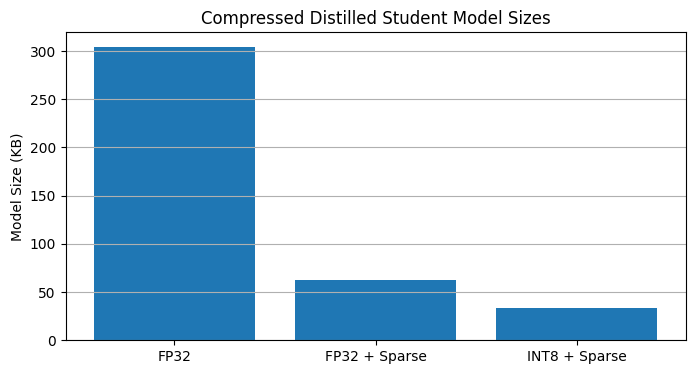

In [22]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


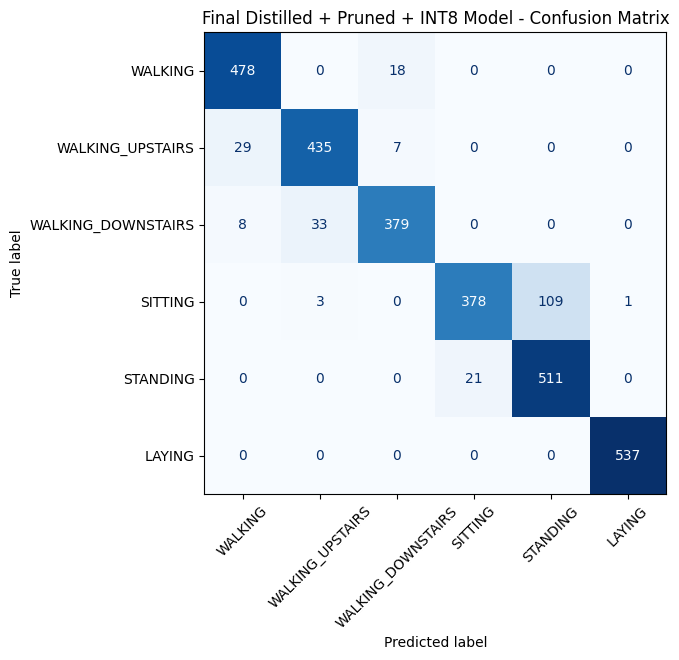

In [23]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
   The baseline performed slightly better.
3. Did **knowledge distillation** help the smaller model retain performance?
   It did not have a signficant impact.
5. What happened to the model size after **pruning** and after **INT8 quantization**?
   It reduced the number of active weights in the model and quantization reduces model size.
7. Which model would you choose for **Arduino deployment**, and why?
   The sparse INT8 model as it has the best balance between performance and accuracy.
9. Why is the final **sparse INT8 model** a good TinyML deployment candidate?
    It is a good candidate because it reduces zero weights and reduces memory usage.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
